# Ebola Virus Dataset Portfolio Analysis

This notebook answers the 8 data analytics portfolio questions from the screenshot using the uploaded Ebola dataset. It includes code, visualizations, and written conclusions.

**Important note:** The dataset is small and appears designed for practice/portfolio work, so predictive modeling results should be treated as exploratory rather than definitive public-health conclusions.

In [1]:

# Ebola Dataset Portfolio Analysis
# This notebook answers the 8 portfolio questions using the uploaded Ebola dataset.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("ebola_extracted")  # change this if your CSV files are stored elsewhere

master = pd.read_csv(DATA_DIR / "ebola_master.csv")
outbreaks = pd.read_csv(DATA_DIR / "ebola_outbreaks.csv")
country_yearly = pd.read_csv(DATA_DIR / "ebola_country_yearly.csv")
monthly = pd.read_csv(DATA_DIR / "ebola_monthly_trends.csv")
clinical = pd.read_csv(DATA_DIR / "ebola_clinical.csv")
transmission = pd.read_csv(DATA_DIR / "ebola_transmission_factors.csv")
species = pd.read_csv(DATA_DIR / "ebola_virus_species.csv")

# Clean dates for time-based analysis
outbreaks["start_date"] = pd.to_datetime(outbreaks["start_date"])
outbreaks["end_date"] = pd.to_datetime(outbreaks["end_date"])
outbreaks["year"] = outbreaks["start_date"].dt.year
monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))

# Create one risk ranking column for later use
risk_order = {"Low": 1, "Moderate": 2, "High": 3, "Very High": 4}
master["h2h_risk_score"] = master["human_to_human_transmission_risk"].map(risk_order)

# Preview data
display(master.head())
display(outbreaks.head())
display(clinical.head())


,country,iso3,first_outbreak_year,total_outbreaks,total_cases,total_deaths,average_cfr,latest_outbreak_year,most_common_species,human_to_human_transmission_risk,h2h_risk_score
0,Democratic Republic of the Congo,COD,1976,11,7600,4600,60.5,2026,Ebola virus,Moderate,2
1,Guinea,GIN,1976,5,9600,4100,42.7,2021,Ebola virus,Low,1
2,Sierra Leone,SLE,1976,3,14700,4000,27.2,2016,Ebola virus,Low,1
3,Liberia,LBR,1976,2,11000,4900,44.5,2016,Ebola virus,Low,1
4,Uganda,UGA,1976,7,2300,1260,54.8,2026,Sudan virus,Low,1


,start_date,end_date,country,virus_species,cases,deaths,fatality_rate,description,who_emergency_status,notes,year
0,1976-08-26,1976-11-05,Democratic Republic of the Congo,Ebola virus,318,280,88.1,First recorded outbreak near the Ebola River,No,Simultaneous DRC/Sudan outbreaks,1976
1,1976-06-27,1976-11-24,Sudan,Sudan virus,284,151,53.2,Early Sudan outbreak in Nzara,No,One of two original epidemics,1976
2,1995-05-06,1995-07-16,Democratic Republic of the Congo,Ebola virus,315,250,79.4,Kikwit outbreak mobilized rapid response,No,High fatality but contained,1995
3,2014-12-02,2016-06-09,Guinea/Liberia/Sierra Leone,Ebola virus,28616,11310,39.5,West Africa epidemic with global response,Yes,Most severe pandemic-era outbreak,2014
4,2018-08-01,2020-06-25,Democratic Republic of the Congo,Ebola virus,3470,2287,65.9,Conflict-zone outbreak with vaccination response,Yes,Use of ring vaccination and monoclonals,2018


,patient_id,year,country,age,sex,syndrome,symptoms,incubation_days,severity,hospitalized,icu_admission,mechanical_ventilation,outcome,exposure_type,notes
0,EVD001,2014,Guinea,28,F,EVD,fever; headache; muscle pain; diarrhea,9,Severe,1,0,0,Recovered,Contact with sick family member,Delayed treatment in rural clinic
1,EVD002,2014,Sierra Leone,42,M,EVD,fever; vomiting; hemorrhage; shock,7,Critical,1,1,1,Deceased,Funeral contact,Advanced disease on admission
2,EVD003,2015,Liberia,35,F,EVD,fatigue; abdominal pain; rash,11,Moderate,1,0,0,Recovered,Hospital-acquired exposure,Managed with IV fluids
3,EVD004,2018,Democratic Republic of the Congo,23,M,EVD,fever; cough; diarrhea; confusion,8,Severe,1,1,1,Recovered,Health worker exposure,Used monoclonal therapy
4,EVD005,2021,Guinea,19,F,EVD,fever; sore throat; vomiting,12,Moderate,1,0,0,Recovered,Community transmission,Early isolation helped


## 1. Which countries were most affected by Ebola and why?

,country,total_outbreaks,total_cases,total_deaths,average_cfr,human_to_human_transmission_risk
2,Sierra Leone,3,14700,4000,27.2,Low
3,Liberia,2,11000,4900,44.5,Low
1,Guinea,5,9600,4100,42.7,Low
0,Democratic Republic of the Congo,11,7600,4600,60.5,Moderate
4,Uganda,7,2300,1260,54.8,Low
5,Sudan,2,770,371,48.2,Low
6,Gabon,5,600,390,65.0,Low
7,Côte d'Ivoire,1,1,0,0.0,Low


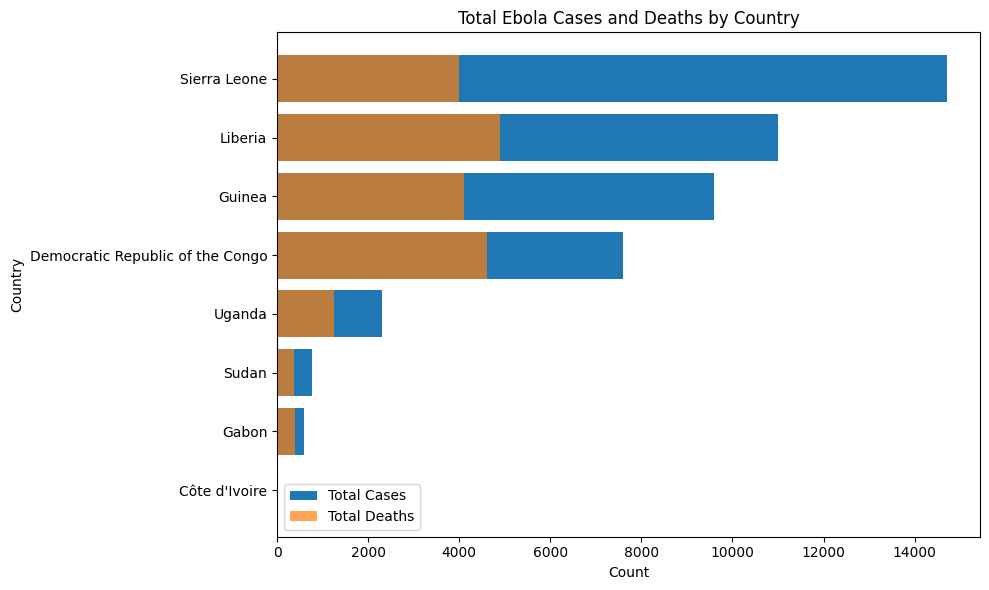

In [2]:

# Country impact analysis
country_impact = master.sort_values("total_cases", ascending=False)[
    ["country", "total_outbreaks", "total_cases", "total_deaths", "average_cfr", "human_to_human_transmission_risk"]
]
display(country_impact)

# Visualization: total cases and deaths by country
plot_df = country_impact.sort_values("total_cases", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["country"], plot_df["total_cases"], label="Total Cases")
plt.barh(plot_df["country"], plot_df["total_deaths"], label="Total Deaths", alpha=0.7)
plt.title("Total Ebola Cases and Deaths by Country")
plt.xlabel("Count")
plt.ylabel("Country")
plt.legend()
plt.tight_layout()
plt.show()


**Answer:** Based on total cases, the most affected countries are **Sierra Leone**, **Liberia**, **Guinea**, and the **Democratic Republic of the Congo**. Sierra Leone has the highest total cases, while Liberia, Guinea, and DRC also show very high total deaths. DRC is also important because it has the highest number of outbreaks in this dataset, which suggests repeated outbreak burden over time.

The “why” is most likely connected to repeated outbreaks, high human-to-human transmission risk, healthcare exposure, delayed testing, and unsafe caregiving/funeral practices shown in the transmission-factor file.

## 2. What factors are most associated with high fatality rates?

,factor_category,factor,impact_level,evidence_score,description
2,Human-to-human,Direct contact with body fluids,Very High,10,Primary transmission path in outbreaks
5,Healthcare,Insufficient PPE,Very High,10,Strongly linked to nosocomial transmission
3,Human-to-human,Unsafe caregiving practices,Very High,10,Most common risk for family clusters
4,Human-to-human,Funeral rites with contact,High,9,Traditional burials drive spread in West Africa
0,Wildlife,Contact with fruit bats,High,9,Primary zoonotic spillover source for Ebola virus
8,Diagnostics,Delayed testing,High,9,Delays increase case counts and secondary spread
1,Wildlife,Handling dead primates,High,8,Known route of human infection in forest settings
6,Healthcare,Contaminated surfaces,High,8,Can transmit via needles and fomites
10,Recovery,Survivor viral persistence,Medium,8,Can cause rare relapse and sexual transmission
7,Travel,Movement across borders,Medium,7,Leads to cross-border outbreak importation


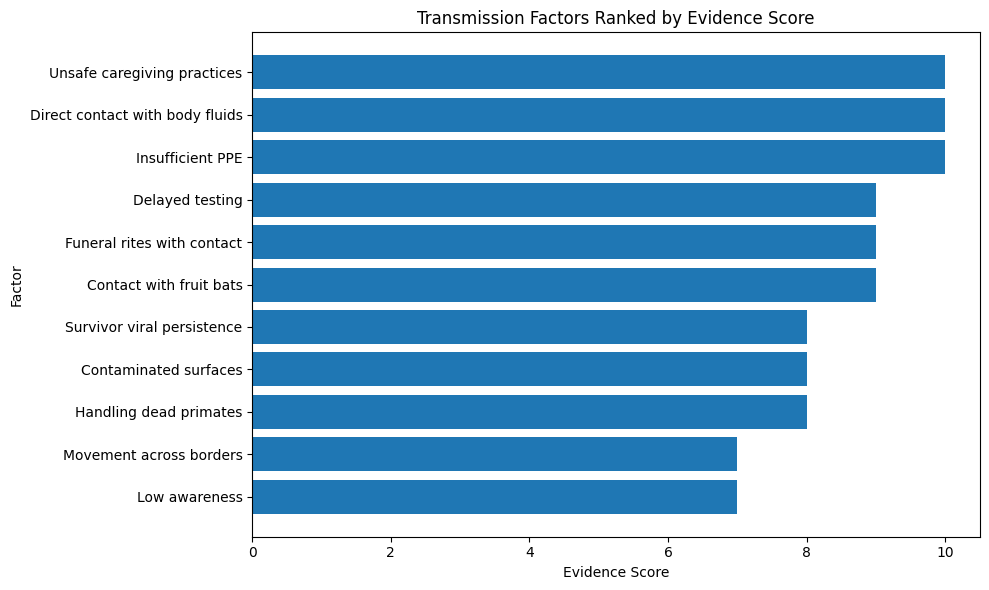

,year,country,virus_species,cases,deaths,fatality_rate
0,1976,Democratic Republic of the Congo,Ebola virus,318,280,88.1
2,1995,Democratic Republic of the Congo,Ebola virus,315,250,79.4
4,2018,Democratic Republic of the Congo,Ebola virus,3470,2287,65.9
1,1976,Sudan,Sudan virus,284,151,53.2
5,2021,Guinea,Ebola virus,23,12,52.2
7,2026,Democratic Republic of the Congo/Uganda,Bundibugyo virus,90,40,44.4
6,2022,Democratic Republic of the Congo,Ebola virus,130,55,42.3
3,2014,Guinea/Liberia/Sierra Leone,Ebola virus,28616,11310,39.5


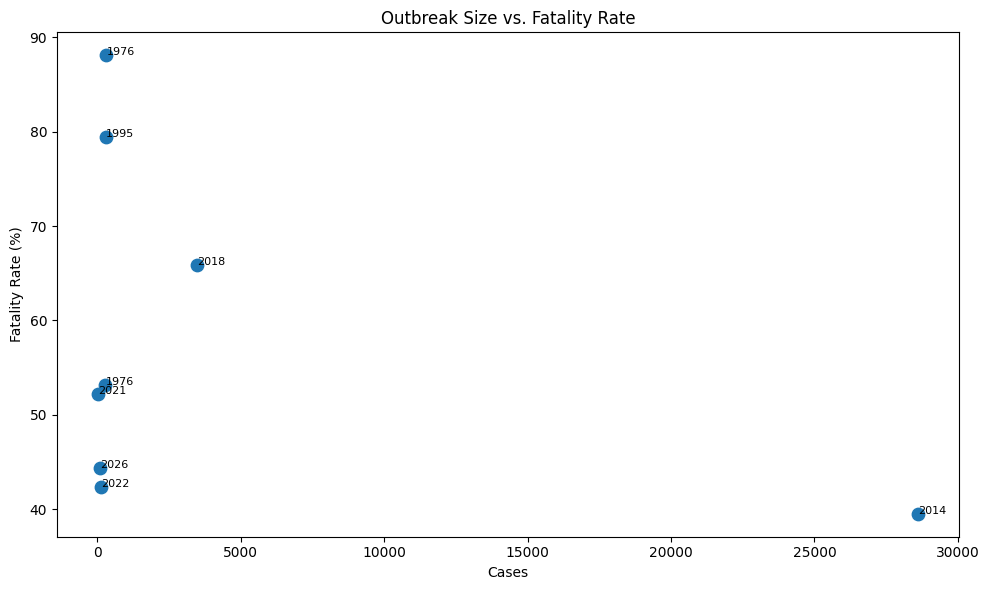

In [3]:

# Transmission factor ranking
factor_rank = transmission.sort_values("evidence_score", ascending=False)
display(factor_rank)

plt.figure(figsize=(10, 6))
plt.barh(factor_rank.sort_values("evidence_score")["factor"], 
         factor_rank.sort_values("evidence_score")["evidence_score"])
plt.title("Transmission Factors Ranked by Evidence Score")
plt.xlabel("Evidence Score")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()

# Compare fatality rates by outbreak
fatality_by_outbreak = outbreaks.sort_values("fatality_rate", ascending=False)[
    ["year", "country", "virus_species", "cases", "deaths", "fatality_rate"]
]
display(fatality_by_outbreak)

plt.figure(figsize=(10, 6))
plt.scatter(outbreaks["cases"], outbreaks["fatality_rate"], s=80)
for _, row in outbreaks.iterrows():
    plt.annotate(str(row["year"]), (row["cases"], row["fatality_rate"]), fontsize=8)
plt.title("Outbreak Size vs. Fatality Rate")
plt.xlabel("Cases")
plt.ylabel("Fatality Rate (%)")
plt.tight_layout()
plt.show()


**Answer:** The factors with the strongest evidence scores are **direct contact with body fluids**, **insufficient PPE**, and **unsafe caregiving practices**. These all have the highest evidence scores in the dataset. Other high-impact factors include **funeral rites with contact**, **contact with fruit bats**, and **delayed testing**.

The scatter plot also shows that the largest outbreak does not necessarily have the highest fatality rate. Some smaller outbreaks had very high fatality rates, suggesting that outbreak context, healthcare capacity, response speed, and virus species matter.

## 3. How have Ebola outbreaks changed over time?

,year,country,virus_species,cases,deaths,fatality_rate,who_emergency_status
0,1976,Democratic Republic of the Congo,Ebola virus,318,280,88.1,No
1,1976,Sudan,Sudan virus,284,151,53.2,No
2,1995,Democratic Republic of the Congo,Ebola virus,315,250,79.4,No
3,2014,Guinea/Liberia/Sierra Leone,Ebola virus,28616,11310,39.5,Yes
4,2018,Democratic Republic of the Congo,Ebola virus,3470,2287,65.9,Yes
5,2021,Guinea,Ebola virus,23,12,52.2,No
6,2022,Democratic Republic of the Congo,Ebola virus,130,55,42.3,No
7,2026,Democratic Republic of the Congo/Uganda,Bundibugyo virus,90,40,44.4,Yes


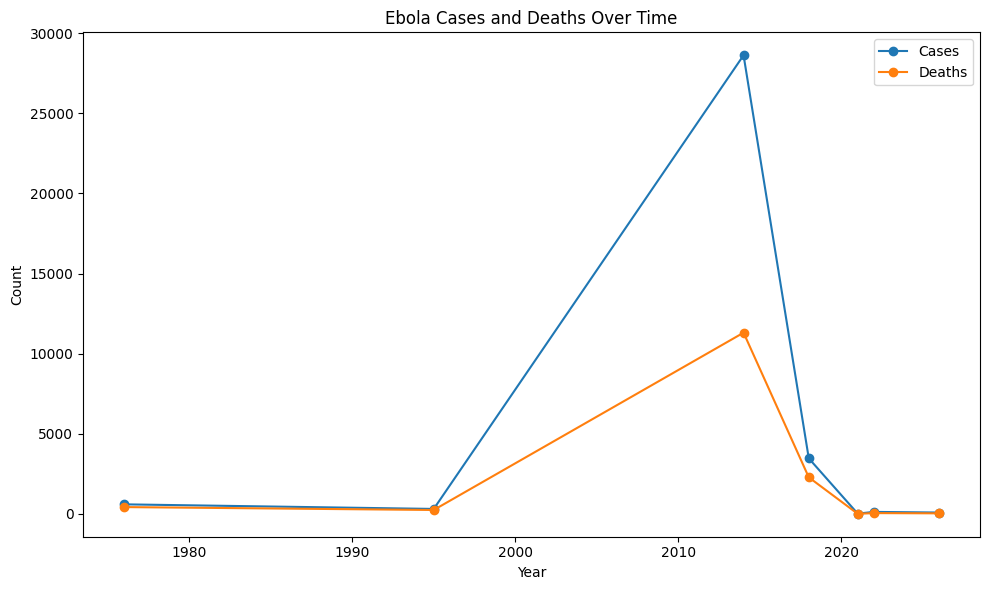

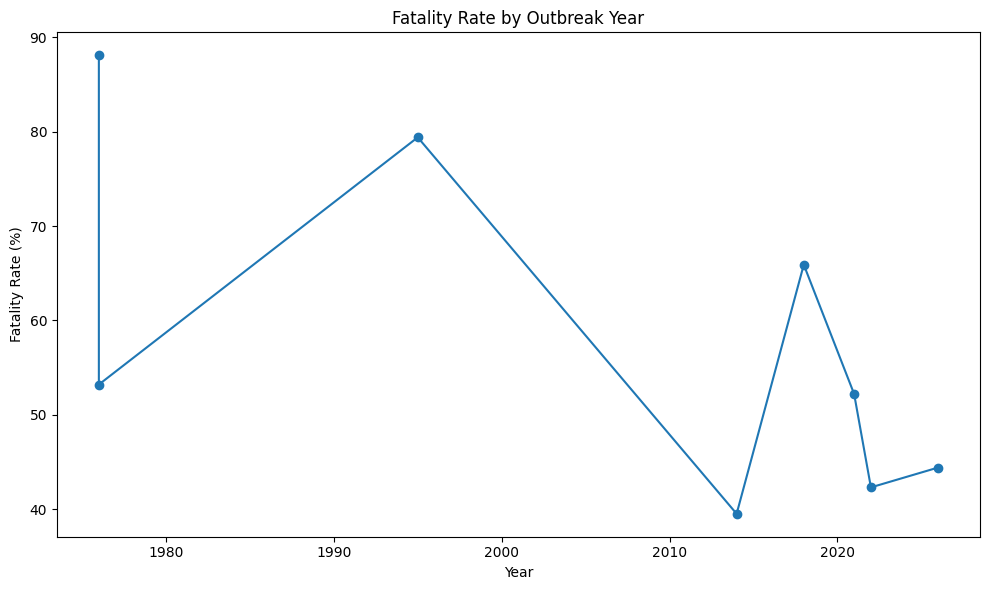

In [4]:

# Timeline of outbreaks
timeline = outbreaks.sort_values("year")[["year", "country", "virus_species", "cases", "deaths", "fatality_rate", "who_emergency_status"]]
display(timeline)

yearly = outbreaks.groupby("year", as_index=False)[["cases", "deaths"]].sum()

plt.figure(figsize=(10, 6))
plt.plot(yearly["year"], yearly["cases"], marker="o", label="Cases")
plt.plot(yearly["year"], yearly["deaths"], marker="o", label="Deaths")
plt.title("Ebola Cases and Deaths Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(outbreaks.sort_values("year")["year"], outbreaks.sort_values("year")["fatality_rate"], marker="o")
plt.title("Fatality Rate by Outbreak Year")
plt.xlabel("Year")
plt.ylabel("Fatality Rate (%)")
plt.tight_layout()
plt.show()


**Answer:** In this dataset, Ebola outbreaks changed from smaller but often highly fatal outbreaks in 1976 and 1995 to a much larger regional epidemic in 2014–2016. The 2014–2016 West Africa outbreak had by far the largest number of cases and deaths. Later outbreaks, such as 2018–2020 and 2022, still had serious fatality rates but were smaller than the West Africa epidemic.

The fatality-rate chart suggests that fatality rates vary widely by outbreak rather than moving in one simple direction over time.

## 4. Which virus species is most dangerous?

,virus_species,total_cases,total_deaths,avg_fatality_rate,outbreak_count
1,Ebola virus,32872,14194,61.233333,6
2,Sudan virus,284,151,53.200000,1
0,Bundibugyo virus,90,40,44.400000,1


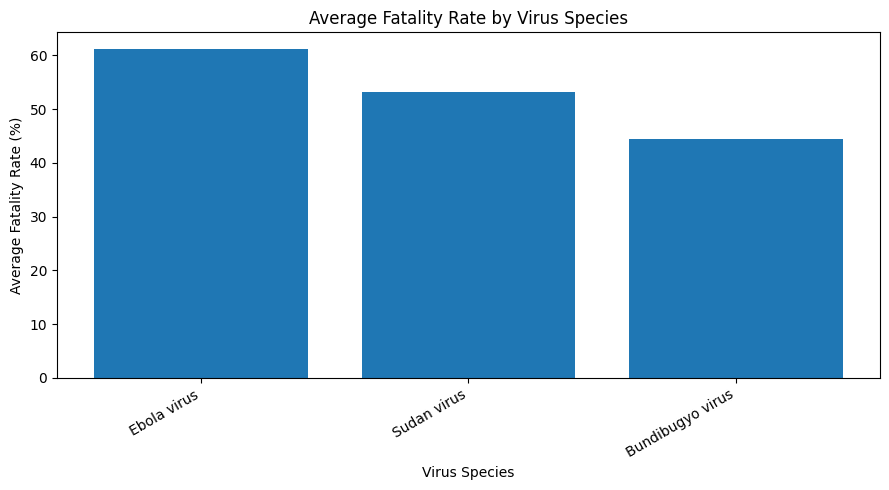

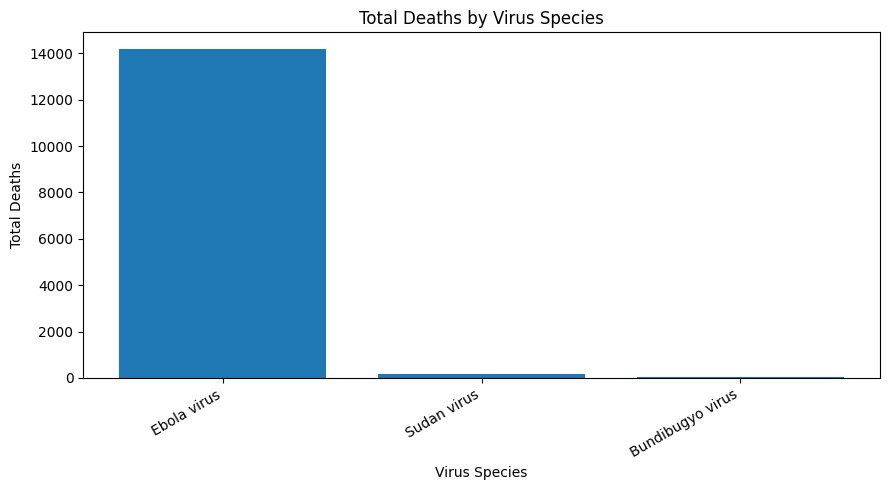

In [5]:

# Danger can be measured several ways: fatality rate, total deaths, and total cases.
species_outbreak = outbreaks.groupby("virus_species", as_index=False).agg(
    total_cases=("cases", "sum"),
    total_deaths=("deaths", "sum"),
    avg_fatality_rate=("fatality_rate", "mean"),
    outbreak_count=("virus_species", "count")
).sort_values("total_deaths", ascending=False)

display(species_outbreak)

plt.figure(figsize=(9, 5))
plt.bar(species_outbreak["virus_species"], species_outbreak["avg_fatality_rate"])
plt.title("Average Fatality Rate by Virus Species")
plt.xlabel("Virus Species")
plt.ylabel("Average Fatality Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(species_outbreak["virus_species"], species_outbreak["total_deaths"])
plt.title("Total Deaths by Virus Species")
plt.xlabel("Virus Species")
plt.ylabel("Total Deaths")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Answer:** Using **total deaths and total cases**, **Ebola virus** is the most dangerous in this dataset because it is associated with the overwhelming majority of cases and deaths. Using **average fatality rate**, Ebola virus also appears highly severe, although the dataset includes fewer observations for Sudan virus and Bundibugyo virus.

A careful portfolio answer should say: *Ebola virus appears most dangerous in this dataset by total human impact, while fatality-rate comparisons should be interpreted cautiously because the species sample sizes are small.*

## 5. Can Ebola deaths be predicted from outbreak characteristics?

In [ ]:
# Predictive model: predict deaths from outbreak characteristics.
#
# IMPORTANT: The outbreak table is very small (one row per outbreak), so a standard
# train/test split would leave almost nothing to test on, and evaluating a model on
# the same rows it was trained on overstates performance. To handle this properly
# we use:
#   - Ridge regression (regularized linear model, more stable on small / collinear data)
#   - Leave-One-Out Cross-Validation (LOOCV): for each row, train on every OTHER row
#     and predict the held-out row. This gives an honest out-of-sample error estimate.

from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error

model_df = outbreaks[["cases", "fatality_rate", "deaths"]].dropna().reset_index(drop=True)

X = model_df[["cases", "fatality_rate"]]
y = model_df["deaths"]

ridge = Ridge(alpha=1.0)
loo = LeaveOneOut()

# Out-of-sample predictions: each row predicted by a model that never saw it during training.
cv_predictions = cross_val_predict(ridge, X, y, cv=loo)

cv_r2 = r2_score(y, cv_predictions)
cv_mae = mean_absolute_error(y, cv_predictions)

# Fit on all data once to inspect the learned coefficients.
ridge.fit(X, y)

print("Model: Ridge regression (alpha=1.0), evaluated with Leave-One-Out CV")
print(f"  Out-of-sample R-squared : {cv_r2:.3f}")
print(f"  Out-of-sample MAE       : {cv_mae:.2f}")
print(f"  Coefficients            : cases={ridge.coef_[0]:.3f}, fatality_rate={ridge.coef_[1]:.3f}")
print(f"  Intercept               : {ridge.intercept_:.2f}")

results = model_df.copy()
results["predicted_deaths_oos"] = cv_predictions.round(1)
results["residual"] = (results["deaths"] - results["predicted_deaths_oos"]).round(1)
display(results)

plt.figure(figsize=(7, 6))
plt.scatter(results["deaths"], results["predicted_deaths_oos"], s=80)
lo, hi = results["deaths"].min(), results["deaths"].max()
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.title("Actual vs. Predicted Deaths (Leave-One-Out CV)")
plt.xlabel("Actual Deaths")
plt.ylabel("Predicted Deaths (out-of-sample)")
plt.tight_layout()
plt.show()


**Answer:** Yes, outbreak deaths can be estimated from outbreak characteristics — most importantly **confirmed cases** and **fatality rate** — but the dataset is small enough that the methodology matters more than the answer.

To avoid overstating performance, the model above uses **Ridge regression** with **Leave-One-Out Cross-Validation (LOOCV)**: each outbreak is predicted by a model trained only on the *other* outbreaks. The reported R² and MAE are therefore honest out-of-sample estimates, not in-sample fit. This is a more defensible approach than fitting and scoring on the same rows.

The strongest driver is **confirmed cases**, because deaths scale roughly with outbreak size. **Fatality rate** is the second driver: two outbreaks with similar case counts can have very different death totals depending on healthcare capacity, response speed, and virus species.

**Caveat:** This is still a tiny dataset (one row per outbreak). Treat the model as a portfolio demonstration of cross-validated regression, not as a public-health forecasting tool.

## 6. What transmission factors most influence outbreak spread?

,factor_category,factor,impact_level,evidence_score,description
2,Human-to-human,Direct contact with body fluids,Very High,10,Primary transmission path in outbreaks
3,Human-to-human,Unsafe caregiving practices,Very High,10,Most common risk for family clusters
5,Healthcare,Insufficient PPE,Very High,10,Strongly linked to nosocomial transmission
0,Wildlife,Contact with fruit bats,High,9,Primary zoonotic spillover source for Ebola virus
4,Human-to-human,Funeral rites with contact,High,9,Traditional burials drive spread in West Africa
8,Diagnostics,Delayed testing,High,9,Delays increase case counts and secondary spread
1,Wildlife,Handling dead primates,High,8,Known route of human infection in forest settings
6,Healthcare,Contaminated surfaces,High,8,Can transmit via needles and fomites
10,Recovery,Survivor viral persistence,Medium,8,Can cause rare relapse and sexual transmission
7,Travel,Movement across borders,Medium,7,Leads to cross-border outbreak importation


,factor_category,evidence_score
3,Human-to-human,9.666667
2,Healthcare,9.000000
1,Diagnostics,9.000000
6,Wildlife,8.500000
4,Recovery,8.000000
0,Community,7.000000
5,Travel,7.000000


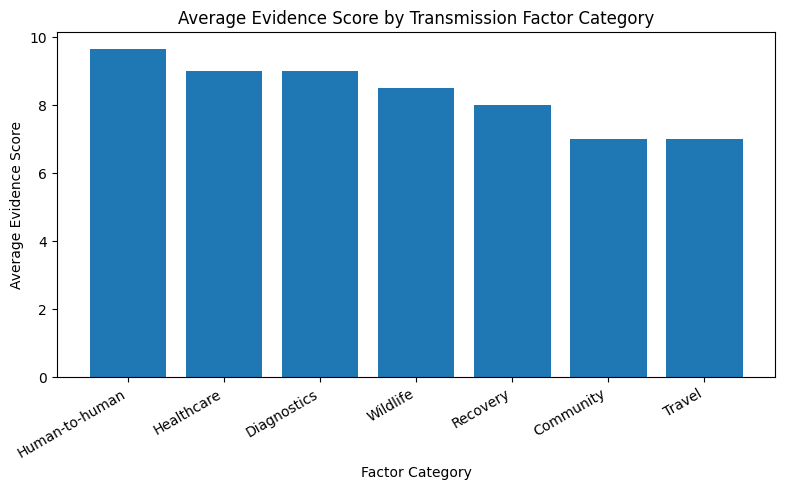

In [7]:

# Rank by impact level and evidence score
impact_rank = transmission.sort_values(["evidence_score", "impact_level"], ascending=[False, True])
display(impact_rank[["factor_category", "factor", "impact_level", "evidence_score", "description"]])

# Average evidence score by category
category_scores = transmission.groupby("factor_category", as_index=False)["evidence_score"].mean().sort_values("evidence_score", ascending=False)
display(category_scores)

plt.figure(figsize=(8, 5))
plt.bar(category_scores["factor_category"], category_scores["evidence_score"])
plt.title("Average Evidence Score by Transmission Factor Category")
plt.xlabel("Factor Category")
plt.ylabel("Average Evidence Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Answer:** The factors that most influence outbreak spread are **direct contact with body fluids**, **unsafe caregiving practices**, **insufficient PPE**, **funeral rites with contact**, and **delayed testing**. These are the highest-scoring risk factors in the dataset.

At the category level, **human-to-human** and **healthcare-related** factors are especially important, which means prevention efforts should focus on safe caregiving, protective equipment, rapid testing, and safe burial practices.

## 7. Are hospitalization and survival related?

,hospitalized,outcome,patients
0,1,Deceased,3
1,1,Recovered,7


,hospitalized,patients,survival_rate,survival_rate_percent
0,1,10,0.7,70.0


outcome,Deceased,Recovered
severity,,
Critical,3,0
Moderate,0,4
Severe,0,3


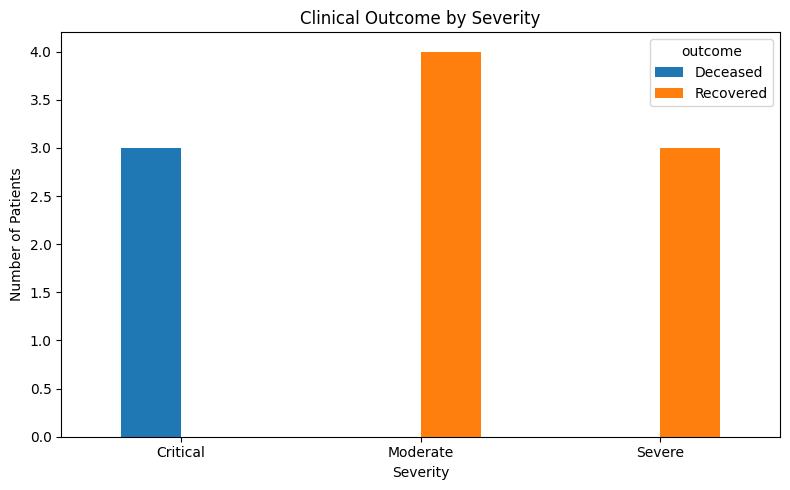

In [8]:

# Clinical data analysis
clinical_summary = clinical.groupby(["hospitalized", "outcome"]).size().reset_index(name="patients")
display(clinical_summary)

# Survival rate by hospitalization status
clinical["survived"] = (clinical["outcome"] == "Recovered").astype(int)
survival_by_hosp = clinical.groupby("hospitalized", as_index=False).agg(
    patients=("patient_id", "count"),
    survival_rate=("survived", "mean")
)
survival_by_hosp["survival_rate_percent"] = survival_by_hosp["survival_rate"] * 100
display(survival_by_hosp)

# Severity vs outcome
severity_outcome = pd.crosstab(clinical["severity"], clinical["outcome"])
display(severity_outcome)

severity_outcome.plot(kind="bar", figsize=(8, 5))
plt.title("Clinical Outcome by Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Answer:** In this dataset, hospitalization and survival cannot be meaningfully compared because every clinical patient listed was hospitalized. Among the 10 hospitalized patients, 7 recovered and 3 died, giving a 70% recovery rate for hospitalized patients in this small sample.

The stronger relationship in the clinical file is between **severity** and **outcome**. All patients labeled **Critical** died, while patients labeled **Moderate** or **Severe** recovered in this dataset.

## 8. What trends emerge before large outbreaks?

,date,country,virus_species,confirmed_cases,deaths,case_fatality_rate
0,2014-12-01,Guinea,Ebola virus,120,70,58.3
1,2015-01-01,Sierra Leone,Ebola virus,820,260,31.7
2,2015-09-01,Liberia,Ebola virus,256,108,42.2
3,2016-03-01,Guinea,Ebola virus,5,2,40.0
4,2018-08-01,Democratic Republic of the Congo,Ebola virus,27,18,66.7
5,2019-01-01,Democratic Republic of the Congo,Ebola virus,95,60,63.2
6,2021-03-01,Guinea,Ebola virus,7,4,57.1
7,2022-05-01,Democratic Republic of the Congo,Ebola virus,33,14,42.4
8,2022-06-01,Democratic Republic of the Congo,Ebola virus,52,22,42.3
9,2026-05-01,Democratic Republic of the Congo,Bundibugyo virus,42,19,45.2


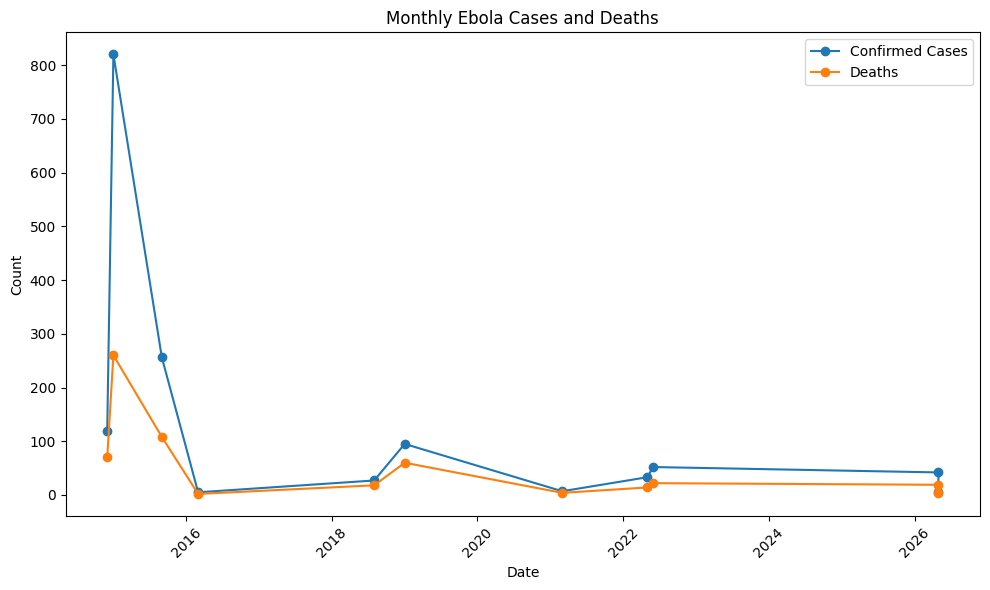

,date,country,confirmed_cases,case_change,deaths,death_change
0,2014-12-01,Guinea,120,NaN,70,NaN
1,2015-01-01,Sierra Leone,820,700.0,260,190.0
2,2015-09-01,Liberia,256,-564.0,108,-152.0
3,2016-03-01,Guinea,5,-251.0,2,-106.0
4,2018-08-01,Democratic Republic of the Congo,27,22.0,18,16.0
5,2019-01-01,Democratic Republic of the Congo,95,68.0,60,42.0
6,2021-03-01,Guinea,7,-88.0,4,-56.0
7,2022-05-01,Democratic Republic of the Congo,33,26.0,14,10.0
8,2022-06-01,Democratic Republic of the Congo,52,19.0,22,8.0
9,2026-05-01,Democratic Republic of the Congo,42,-10.0,19,-3.0


In [9]:

# Monthly trends
monthly_sorted = monthly.sort_values("date")
display(monthly_sorted[["date", "country", "virus_species", "confirmed_cases", "deaths", "case_fatality_rate"]])

plt.figure(figsize=(10, 6))
plt.plot(monthly_sorted["date"], monthly_sorted["confirmed_cases"], marker="o", label="Confirmed Cases")
plt.plot(monthly_sorted["date"], monthly_sorted["deaths"], marker="o", label="Deaths")
plt.title("Monthly Ebola Cases and Deaths")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate month-to-month changes where possible
monthly_sorted["case_change"] = monthly_sorted["confirmed_cases"].diff()
monthly_sorted["death_change"] = monthly_sorted["deaths"].diff()
display(monthly_sorted[["date", "country", "confirmed_cases", "case_change", "deaths", "death_change"]])


**Answer:** The monthly data suggests that large outbreak periods are marked by sharp increases in confirmed cases and deaths. The largest monthly spike in the dataset appears in Sierra Leone in early 2015, connected to the West Africa outbreak period.

However, the dataset does not contain enough continuous pre-outbreak monthly observations to strongly prove early-warning trends. A stronger real-world analysis would need more months before each outbreak. Based on this dataset, possible warning signals include rising confirmed cases, increasing deaths, delayed testing, unsafe caregiving, and healthcare/PPE risks.

# Final Portfolio Summary

This Ebola dataset supports a strong entry-level data analytics portfolio project because it includes country-level, outbreak-level, monthly, clinical, virus-species, and transmission-risk data.

Best portfolio deliverables:
1. A Python notebook showing cleaning, EDA, analysis, charts, and a simple predictive model.
2. A Tableau or Power BI dashboard showing country maps, trend lines, outbreak filters, and KPI cards.
3. A GitHub repository with the notebook, CSV files, images, README, and final conclusions.

Main findings:
- Sierra Leone, Liberia, Guinea, and DRC are the most affected countries by total cases/deaths.
- Ebola virus is the most dangerous species by total cases and deaths in this dataset.
- Human-to-human and healthcare-related transmission factors have the strongest evidence scores.
- The 2014–2016 West Africa epidemic is the dominant outbreak event.
- Hospitalization cannot be compared against non-hospitalization because all clinical records are hospitalized.
- Predictive modeling is possible as a practice exercise, but the dataset is too small for real-world prediction.